# Notebook 13 — KymoRoPE: decodificación a trayectorias y comparación con KymoButler

KymoRoPE (notebook 12) no devuelve trayectorias: devuelve tres mapas por píxel — _trackness_
(fondo / estática / móvil), _embedding_ 8-D y _orientación_. Este notebook los convierte en
trayectorias y las mide contra el ground truth y contra KymoButler, con **el mismo harness**
(`evaluacion.evaluar_trayectorias_polilineas`: sólo móviles ≥ 8 px, asociación por fila a ≤ 4 px,
voto por mayoría) que ya midió a Mask2Former y YOLO+SAM3.

**El decode** (`src/axonal_tracking/decodificacion.py`):

```
p(móvil) ≥ umbral            máscara móvil
  → componentes conexas       conectividad PRIMERO
  → mean-shift del embedding  dentro de cada componente
  → seguir en cadenas         una posición por fila, por predicción de pendiente
  → enlazar fragmentos        entre componentes: posición + embedding
  → línea central → extraer_subpixel
  → filtro de movilidad       mismo criterio que el GT del harness
```

**Una versión anterior del decode se descartó por medición.** Cortaba la trayectoria ante
cualquier ambigüedad (dos corridas en una fila) en vez de seguirla. Con trackness **e** identidad
GT — o sea con el decode como única fuente de error — daba 1.37 trayectorias por partícula en
val, peor que KymoButler entero (1.27), y 401 de las 408 partículas fragmentadas eran partículas
que cruzan a otra: en un cruce la otra traza tapa a esta y quedan astillas o filas vacías. El
seguimiento por predicción lo baja a 1.14 con las mismas entradas. Los números de esa versión
quedan en `results/kymorope/decode/val_v1_corte/`.

**Dónde corre cada cosa.** Las corridas largas son scripts, este notebook sólo lee sus salidas:

|            | comando                                                       | salida                         |
| ---------- | ------------------------------------------------------------- | ------------------------------ |
| KymoButler | `uv run python scripts/evaluar_kymobutler_400.py --split val` | `results/kymobutler/*_val*`    |
| KymoRoPE   | `uv run python scripts/evaluar_kymorope.py --split val`       | `results/kymorope/decode/val/` |

**Todo es val.** El punto de operación del decode se elige acá, sobre val. Test se corre **una sola
vez**, al final, con ese punto fijo: elegirlo mirando test contamina el gate.


In [ ]:
import json
import pickle
import sys
from dataclasses import replace
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D

RAIZ = Path("..").resolve()
sys.path.append(str(RAIZ / "src"))

from axonal_tracking import datos_pixel as dp
from axonal_tracking import decodificacion as dc
from axonal_tracking import etiquetas_deteccion as ed
from axonal_tracking import evaluacion as ev
from axonal_tracking import kymorope as kr

SPLIT = "val"  # test: una sola corrida al final, con el punto de operacion elegido aca
MIN_DESP = ed.MIN_DESPLAZAMIENTO_PX_MOVIL
# que modelo: None = el de 800 muestras (resultados en decode/val), o el nombre de una
# corrida de NB12 §7 evaluada con `evaluar_kymorope.py --checkpoint`, p.ej. "finetune_5k"
CORRIDA = None
DIR_KR = RAIZ / "results" / "kymorope" / "decode" / (SPLIT if CORRIDA is None else f"{SPLIT}_{CORRIDA}")
DIR_KB = RAIZ / "results" / "kymobutler"
CHECKPOINT = (
    RAIZ / "results" / "kymorope" / "checkpoints" / "kymorope_40ep_2026-09-24.pt"
    if CORRIDA is None
    else RAIZ / "results" / "kymorope" / "checkpoints" / CORRIDA / "checkpoint_final.pt"
)
VARIANTE_KB = (
    "solo_moviles_subpixel"  # la comparable: misma ruta de extraccion que KymoRoPE
)

for ruta, comando in (
    (DIR_KR / "resumen.json", f"scripts/evaluar_kymorope.py --split {SPLIT}"),
    (
        DIR_KB / f"resumen_{SPLIT}.json",
        f"scripts/evaluar_kymobutler_400.py --split {SPLIT}",
    ),
):
    if not ruta.exists():
        raise FileNotFoundError(f"Falta {ruta}: correr `uv run python {comando}`")

res_kr = json.loads((DIR_KR / "resumen.json").read_text())
res_kb = json.loads((DIR_KB / f"resumen_{SPLIT}.json").read_text())
PUNTO = res_kr["punto_de_operacion"]
# Un resumen anterior al 2026-09-26 no trae las opciones que se agregaron despues (centro
# desde la mascara, enlace estricto en zonas densas): esa corrida las tenia apagadas, asi
# que se completan apagadas y §4 reproduce exactamente la corrida que hay en disco.
_params = res_kr["filas"][PUNTO]["params"]
PARAMS_PUNTO = dc.ParametrosDecode(
    **{
        "centro_desde_mascara": False,
        "margen_enlace": 0.0,
        "max_dist_emb_denso": _params.get("max_dist_emb_enlace", 1.5),
        **_params,
    }
)
print(
    f"{SPLIT}: KymoRoPE {res_kr['n_muestras']} muestras, KymoButler {res_kb['n_muestras']} "
    f"({len(res_kb['fallos'])} fallos)"
)
print(f"punto de operacion elegido en {SPLIT}: {PUNTO}")
print(f"  regla: {res_kr['regla']}")

# muestras con su kimografo CRUDO y su GT, compartidas por todas las secciones
escenas = {
    d.name: ev.cargar_escena_sintetica(d)
    for d in sorted((RAIZ / "datasets" / SPLIT).glob("sample_*"))
}


def con_polilineas(ruta_pkl):
    """Escenas + las polilineas guardadas por un script, listas para el harness."""
    with open(ruta_pkl, "rb") as f:
        polis = pickle.load(f)
    return {n: {**escenas[n], "polilineas": polis[n]} for n in polis}


esc_kr = con_polilineas(DIR_KR / f"polilineas_{PUNTO}.pkl")
esc_kb = con_polilineas(DIR_KB / f"polilineas_{SPLIT}_{VARIANTE_KB}.pkl")
tr_kr = pd.read_csv(DIR_KR / f"trayectorias_{PUNTO}.csv")
tr_kb = pd.read_csv(DIR_KB / f"trayectorias_{SPLIT}_{VARIANTE_KB}.csv")

val: KymoRoPE 400 muestras, KymoButler 400 (0 fallos)
punto de operacion elegido en val: M2_h1.5_w0_enlace40
  regla: min frac_id_switch + frac_gt_fragmentado con track_f1 >= mejor M2 - 0.01


---

## 1. Tabla principal — KymoButler contra la escalera diagnóstica

Cada fila de KymoRoPE aísla una pieza, para que cada cifra se pueda atribuir:

| fila | trackness | identidad            | qué aísla                                                                           |
| ---- | --------- | -------------------- | ----------------------------------------------------------------------------------- |
| D0   | GT        | GT                   | techo del decode + métrica. **Tiene que dar F1 ≈ 1**: si no, el decode tiene un bug |
| D1   | GT        | ninguna              | lo que da la geometría sola (conectividad + seguimiento por pendiente)              |
| D2   | GT        | embedding del modelo | el embedding aislado                                                                |
| M1   | modelo    | ninguna              | trackness del modelo + geometría                                                    |
| M2   | modelo    | embedding del modelo | el sistema real; barrido de ancho de banda `h` y peso de orientación `w`            |

`_enlace40`: con enlace de fragmentos entre componentes (hueco de hasta 40 filas), siempre con
identidad — el enlace sólo geométrico disparaba el id-switch a 0.17–0.19 en la primera corrida.

**Cómo leer la escalera.** D0 → D1 es lo que se pierde sin identidad; D1 → D2, lo que el
embedding del modelo recupera con la máscara perfecta; D2 → M2, lo que cuesta el trackness del
modelo. El punto de operación (regla en la salida de §0) es la fila M2 con menor
`id-switch + GT fragm.` entre las de F1 a ≤ 0.01 de la mejor.

**KymoButler, dos filas.** `subpixel` pasa sus trayectorias por la misma extracción que KymoRoPE
(rasterizar fino → `extraer_subpixel`): es **la comparable**. `esqueleto` es su salida cruda, a
coordenadas enteras; queda de referencia, porque la ruta de extracción mueve el piso de
`id-switch` (0.005 contra 0.132 en test, `scripts/evaluar_kymobutler_400.py`).

Métricas: `id-switch` = fracción de trayectorias predichas que mezclan dos partículas;
`fragm./GT` = trayectorias predichas por partícula recuperada (1 = ideal); `GT fragm.` = fracción
de partículas partidas en más de una.


In [2]:
COLUMNAS = {
    "track_f1": "F1",
    "track_precision": "precision",
    "track_recall": "recall",
    "frac_id_switch": "id-switch",
    "fragmentos_por_gt": "fragm./GT",
    "frac_gt_fragmentado": "GT fragm.",
    "err_pos_um_medio": "err pos (um)",
    "err_vel_um_s_mediana": "err vel med (um/s)",
}
filas = {
    "KymoButler · subpixel (comparable)": res_kb["resultados"][VARIANTE_KB],
    "KymoButler · esqueleto crudo": res_kb["resultados"]["solo_moviles"],
}
for nombre, r in res_kr["filas"].items():
    marca = "  <- punto de operacion" if nombre == PUNTO else ""
    filas[f"KymoRoPE · {nombre}{marca}"] = r
tabla = (
    pd.DataFrame(filas)
    .T[list(COLUMNAS)]
    .rename(columns=COLUMNAS)
    .astype(float)
    .round(3)
)
display(tabla)

# Las cuatro barras del gate contra la fila comparable de KymoButler, en val
kb, kr_ = res_kb["resultados"][VARIANTE_KB], res_kr["filas"][PUNTO]
barras = [
    ("track_f1", "F1", ">="),
    ("frac_id_switch", "id-switch", "<"),
    ("fragmentos_por_gt", "fragm./GT", "<="),
    ("err_pos_um_medio", "err pos (um)", "<"),
]
gate = pd.DataFrame(
    [
        {
            "barra": nombre,
            "KymoButler": kb[k],
            "KymoRoPE": kr_[k],
            "KymoRoPE gana": {
                ">=": kr_[k] >= kb[k],
                "<": kr_[k] < kb[k],
                "<=": kr_[k] <= kb[k],
            }[op],
        }
        for k, nombre, op in barras
    ]
).set_index("barra")
print(f"\nGate en {SPLIT} (KymoRoPE = {PUNTO}; KymoButler = {VARIANTE_KB}):")
display(gate)

,F1,precision,recall,id-switch,fragm./GT,GT fragm.,err pos (um),err vel med (um/s)
KymoButler · subpixel (comparable),0.972,0.999,0.947,0.105,1.273,0.203,0.032,0.014
KymoButler · esqueleto crudo,0.973,0.999,0.948,0.103,1.273,0.201,0.053,0.014
KymoRoPE · D0_gt_oraculo,0.998,0.998,0.998,0.024,1.135,0.100,0.034,0.001
KymoRoPE · D0_gt_oraculo_enlace40,0.998,0.998,0.998,0.025,1.118,0.088,0.034,0.001
KymoRoPE · D1_gt_sin_embedding,0.986,0.998,0.974,0.183,1.228,0.169,0.030,0.003
KymoRoPE · D2_gt_embedding,0.980,0.996,0.964,0.100,1.373,0.174,0.048,0.005
KymoRoPE · M1_sin_embedding,0.976,0.997,0.956,0.158,1.376,0.256,0.036,0.026
KymoRoPE · M2_h1_w0,0.983,0.997,0.970,0.074,1.740,0.302,0.057,0.051
KymoRoPE · M2_h1_w0_enlace40,0.984,0.996,0.973,0.092,1.600,0.258,0.060,0.030
KymoRoPE · M2_h1.5_w0,0.976,0.997,0.955,0.100,1.461,0.247,0.048,0.027



Gate en val (KymoRoPE = M2_h1.5_w0_enlace40; KymoButler = solo_moviles_subpixel):


,KymoButler,KymoRoPE,KymoRoPE gana
barra,,,
F1,0.972,0.977,True
id-switch,0.105,0.116,False
fragm./GT,1.273,1.336,False
err pos (um),0.032,0.049,False


---

## 2. Estratificado — dónde gana y dónde pierde cada uno

Dos cortes, los dos sobre las mismas trayectorias de la tabla anterior:

- **Aspect ratio** (`L / T`, terciles de val): la barra 5 del gate, y la que prueba el argumento de
  la arquitectura. KymoRoPE procesa a resolución nativa; KymoButler redimensiona internamente
  (`scale_factor`), y eso debería costarle más en los extremos.
- **Cruce**: partículas cuya traza toca la de otra móvil (`evaluacion.flaggear_cruces_gt`) contra
  las que nunca tocan a nadie. Una partícula aislada no puede sufrir un id-switch por cruce: ahí
  es donde la identidad se decide de verdad.


In [3]:
relacion = pd.Series(
    {n: e["kymo"].shape[1] / e["kymo"].shape[0] for n, e in escenas.items()}
)
terciles = pd.qcut(relacion, 3)
etiquetas_ar = {
    iv: f"{nombre} (L/T {iv.left:.1f}-{iv.right:.1f})"
    for iv, nombre in zip(terciles.cat.categories, ("1 bajo", "2 medio", "3 alto"))
}
estrato_ar = {n: etiquetas_ar[iv] for n, iv in terciles.items()}

cols_estrato = [
    "n_muestras",
    "track_f1",
    "frac_id_switch",
    "fragmentos_por_gt",
    "err_pos_um_medio",
]
por_ar = pd.concat(
    ev.resumen_por_estrato(esc, estrato_ar, min_desplazamiento_px=MIN_DESP).assign(
        metodo=metodo
    )
    for metodo, esc in (("KymoButler", esc_kb), ("KymoRoPE", esc_kr))
)
print("Por aspect ratio:")
display(por_ar.set_index(["estrato", "metodo"])[cols_estrato].sort_index().round(3))

# cruces: particulas GT cuya mascara toca la de otra movil (mismo ancho de mascara que
# usan los otros pipelines, ver docstring de flaggear_cruces_gt)
ambiguos = {
    n: ev.flaggear_cruces_gt(
        e["positions"], e["pixel_scale_um"], e["kymo"].shape, MIN_DESP
    )
    for n, e in escenas.items()
}
por_cruce = pd.concat(
    ev.resumen_por_cruce(tr, ambiguos).assign(metodo=metodo)
    for metodo, tr in (("KymoButler", tr_kb), ("KymoRoPE", tr_kr))
)
print("Por cruce (solo trayectorias con particula GT asignada):")
display(por_cruce.set_index(["grupo", "metodo"]).sort_index().round(3))

Por aspect ratio:


n_muestras  track_f1  frac_id_switch  \
estrato               metodo                                             
1 bajo (L/T 0.7-4.7)  KymoButler         134     0.984           0.185   
                      KymoRoPE           134     0.986           0.177   
2 medio (L/T 4.7-7.8) KymoButler         133     0.970           0.022   
                      KymoRoPE           133     0.977           0.052   
3 alto (L/T 7.8-32.9) KymoButler         133     0.962           0.025   
                      KymoRoPE           133     0.968           0.040   

                                  fragmentos_por_gt  err_pos_um_medio  
estrato               metodo                                           
1 bajo (L/T 0.7-4.7)  KymoButler              1.605             0.038  
                      KymoRoPE                1.808             0.062  
2 medio (L/T 4.7-7.8) KymoButler              1.089             0.026  
                      KymoRoPE                1.044             0.035  
3 alto (L/T 7.8-32.9) KymoButler              1.036             0.025  
                      KymoRoPE                1.015             0.034

Por cruce (solo trayectorias con particula GT asignada):


n_polilineas  n_gt  frac_id_switch  fragmentos_por_gt  \
grupo     metodo                                                              
con cruce KymoButler          1360   872           0.210              1.560   
          KymoRoPE            1533   845           0.219              1.814   
sin cruce KymoButler          1374  1275           0.001              1.078   
          KymoRoPE            1367  1326           0.001              1.031   

                      frac_gt_fragmentado  err_pos_um_medio  
grupo     metodo                                             
con cruce KymoButler                0.396             0.037  
          KymoRoPE                  0.449             0.063  
sin cruce KymoButler                0.071             0.026  
          KymoRoPE                  0.029             0.033

---

## 3. Superposiciones — las trayectorias, dibujadas

Las muestras no se eligen a mano: se cuentan los errores de KymoRoPE por muestra (trayectorias
con id-switch + fragmentos de más + partículas perdidas) y se toman la mediana, el cuantil 90 y
la peor, entre las muestras con al menos dos móviles. `MUESTRAS_EXTRA` agrega nombres puntuales.

Cada panel lleva el prefijo de dónde sale. En los paneles de cada método, las trayectorias
predichas se pintan por resultado contra el GT:

- **blanco**: sigue a una sola partícula;
- **naranja**: id-switch, mezcla dos partículas;
- **azul**: no corresponde a ninguna partícula móvil del GT;
- **verde agua**: partícula del GT que el método no recuperó (se dibuja el GT).

Los puntos marcan dónde empieza y termina cada trayectoria: dos trayectorias blancas con un
punto en el medio de una misma traza son una partícula fragmentada.


In [4]:
import matplotlib.patheffects as pe

# Los tres errores en las tres primeras ranuras categoricas del modo oscuro, validadas
# todos-contra-todos sobre negro (CVD peor par 9.4, vision normal 20.9); acierto en blanco
# neutro. Solo tres colores de error: un cuarto (rojo) quedaba indistinguible del naranja.
C_OK, C_SWITCH, C_SIN_GT, C_PERDIDA = "#ffffff", "#d95926", "#3987e5", "#199e70"
MUESTRAS_EXTRA = []  # nombres puntuales, p.ej. ["sample_00270"]


def leyenda_resultados(ax, con_extremos=True):
    """Leyenda de los paneles de metodo. La linea blanca lleva contorno gris: sin el,
    desaparece sobre el fondo blanco de la figura."""
    contorno = [pe.Stroke(linewidth=3.6, foreground="#898781"), pe.Normal()]
    items = [
        Line2D([], [], color=C_OK, lw=2, path_effects=contorno, label="una particula"),
        Line2D([], [], color=C_SWITCH, lw=2, label="id-switch"),
        Line2D([], [], color=C_SIN_GT, lw=2, label="sin particula GT"),
        Line2D([], [], color=C_PERDIDA, lw=2, label="GT no recuperada"),
    ]
    if con_extremos:
        items.append(
            Line2D(
                [], [], color="#898781", marker="o", ls="", ms=4, label="inicio / fin"
            )
        )
    ax.legend(
        handles=items,
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        borderaxespad=0,
        frameon=False,
        fontsize=8,
    )


def ids_moviles(escena):
    return ed.ids_que_se_mueven(escena["positions"], escena["pixel_scale_um"], MIN_DESP)


def trazas_gt(escena):
    """particle_id -> (frames, columnas) de cada movil GT, cortada donde no es visible."""
    ancho = escena["kymo"].shape[1]
    px = escena["pixel_scale_um"]
    salida = {}
    for pid in ids_moviles(escena):
        sub = escena["positions"][
            escena["positions"]["particle_id"] == pid
        ].sort_values("frame")
        col = (ancho - 1) - sub["pos_um"].to_numpy() / px
        salida[pid] = (
            sub["frame"].to_numpy(),
            np.where(sub["visible"].to_numpy() == 1, col, np.nan),
        )
    return salida


def errores_por_muestra(tr, esc):
    """Errores de identidad de un metodo por muestra: id-switch + fragmentos de mas + perdidas."""
    filas = []
    for n, e in esc.items():
        t = tr[tr.muestra == n]
        asignadas = t[t.gt_id != -1]
        n_gt = len(ids_moviles(e))
        filas.append(
            {
                "muestra": n,
                "moviles": n_gt,
                "id_switch": int(t.id_switch.sum()),
                "fragmentos_de_mas": len(asignadas) - asignadas.gt_id.nunique(),
                "perdidas": n_gt - asignadas.gt_id.nunique(),
            }
        )
    df = pd.DataFrame(filas).set_index("muestra")
    df["errores"] = df.id_switch + df.fragmentos_de_mas + df.perdidas
    return df


def _lienzo(kymo, atenuar=0.45):
    """Kimografo crudo estirado p50-p99.8 (como el resto del repo) y atenuado."""
    lo, hi = np.percentile(kymo, (50, 99.8))
    return np.clip((kymo.astype(float) - lo) / max(hi - lo, 1e-6), 0, 1) * atenuar


def dibujar_metodo(ax, escena, polis, tr_muestra):
    """Trayectorias de un metodo pintadas por resultado; GT no recuperado en C_PERDIDA."""
    por_caja = tr_muestra.set_index("caja")
    for k, poli in enumerate(polis):
        fila = por_caja.loc[k] if k in por_caja.index else None
        if fila is None or fila.gt_id == -1:
            color = C_SIN_GT
        elif fila.id_switch:
            color = C_SWITCH
        else:
            color = C_OK
        ax.plot(poli.col_subpixel, poli.frame, color=color, lw=1.2)
        ax.plot(
            poli.col_subpixel.iloc[[0, -1]],
            poli.frame.iloc[[0, -1]],
            "o",
            color=color,
            ms=3.5,
            mec="black",
            mew=0.4,
        )
    recuperadas = set(tr_muestra.gt_id[tr_muestra.gt_id != -1])
    for pid, (fr, col) in trazas_gt(escena).items():
        if pid not in recuperadas:
            ax.plot(col, fr, color=C_PERDIDA, lw=1.2)


def ver_comparacion(nombre, etiqueta=""):
    """Cuatro paneles apilados con aspecto 1:1 de pixel: entrada, GT, KymoRoPE, KymoButler."""
    escena = escenas[nombre]
    alto_px, ancho_px = escena["kymo"].shape
    esc = min(13.0 / ancho_px, 2.6 / alto_px)
    ancho, alto = ancho_px * esc, alto_px * esc
    izq, der, sup, inf, titulo = 0.7, 2.4, 0.8, 0.5, 0.35
    hueco = max(alto, 1.05)  # la leyenda de la derecha no pisa la fila de abajo
    W, H = izq + ancho + der, sup + 4 * (titulo + hueco) + inf
    fig = plt.figure(figsize=(W, H))
    axs, cursor = [], H - sup
    for _ in range(4):
        cursor -= titulo + alto
        axs.append(fig.add_axes([izq / W, cursor / H, ancho / W, alto / H]))
        cursor -= hueco - alto

    fondo = _lienzo(escena["kymo"])
    axs[0].imshow(fondo / fondo.max(), cmap="gray", vmin=0, vmax=1, aspect="auto")
    axs[0].set_title("ENTRADA · kimografo crudo (p50-p99.8)", loc="left", fontsize=9)

    trazas = trazas_gt(escena)
    axs[1].imshow(fondo, cmap="gray", vmin=0, vmax=1, aspect="auto")
    for fr, col in trazas.values():
        axs[1].plot(col, fr, color=C_OK, lw=1.2)
    axs[1].set_title(f"GT · {len(trazas)} particulas moviles", loc="left", fontsize=9)

    errores = {}
    for ax, metodo, esc_m, tr_m in (
        (axs[2], "KYMOROPE", esc_kr, tr_kr),
        (axs[3], "KYMOBUTLER", esc_kb, tr_kb),
    ):
        ax.imshow(fondo, cmap="gray", vmin=0, vmax=1, aspect="auto")
        t = tr_m[tr_m.muestra == nombre]
        dibujar_metodo(ax, escena, esc_m[nombre]["polilineas"], t)
        err = errores_por_muestra(t, {nombre: escena}).iloc[0]
        errores[metodo] = err
        ax.set_title(
            f"{metodo} · {len(esc_m[nombre]['polilineas'])} trayectorias · id-switch {err.id_switch} · "
            f"fragmentos de mas {err.fragmentos_de_mas} · perdidas {err.perdidas}",
            loc="left",
            fontsize=9,
        )
        leyenda_resultados(ax)
    for ax in axs:
        ax.set_xlim(-0.5, ancho_px - 0.5)
        ax.set_ylim(alto_px - 0.5, -0.5)
        ax.set_ylabel("t (frame)", fontsize=8)
        ax.tick_params(labelsize=7)
    for ax in axs[:-1]:
        ax.set_xticklabels([])
    axs[-1].set_xlabel("x (px)", fontsize=8)
    fig.suptitle(
        f"{SPLIT} · {nombre} ({etiqueta}) · {alto_px}x{ancho_px} px · {escena['fps']:g} fps · "
        f"KymoRoPE = {PUNTO}, KymoButler = {VARIANTE_KB}",
        x=izq / W,
        y=1 - 0.12 / H,
        ha="left",
        va="top",
        fontsize=10,
    )
    return fig

KymoRoPE                                               \
                      moviles id_switch fragmentos_de_mas perdidas errores   
muestra      caso                                                            
sample_00348 mediana        9         0                 0        0       0   
sample_00272 p90           13         8                 8        0      16   
sample_00257 peor          13        10                23        0      33   

                     KymoButler                                               
                        moviles id_switch fragmentos_de_mas perdidas errores  
muestra      caso                                                             
sample_00348 mediana          9         0                 0        1       1  
sample_00272 p90             13         6                 9        1      16  
sample_00257 peor            13         8                11        0      19

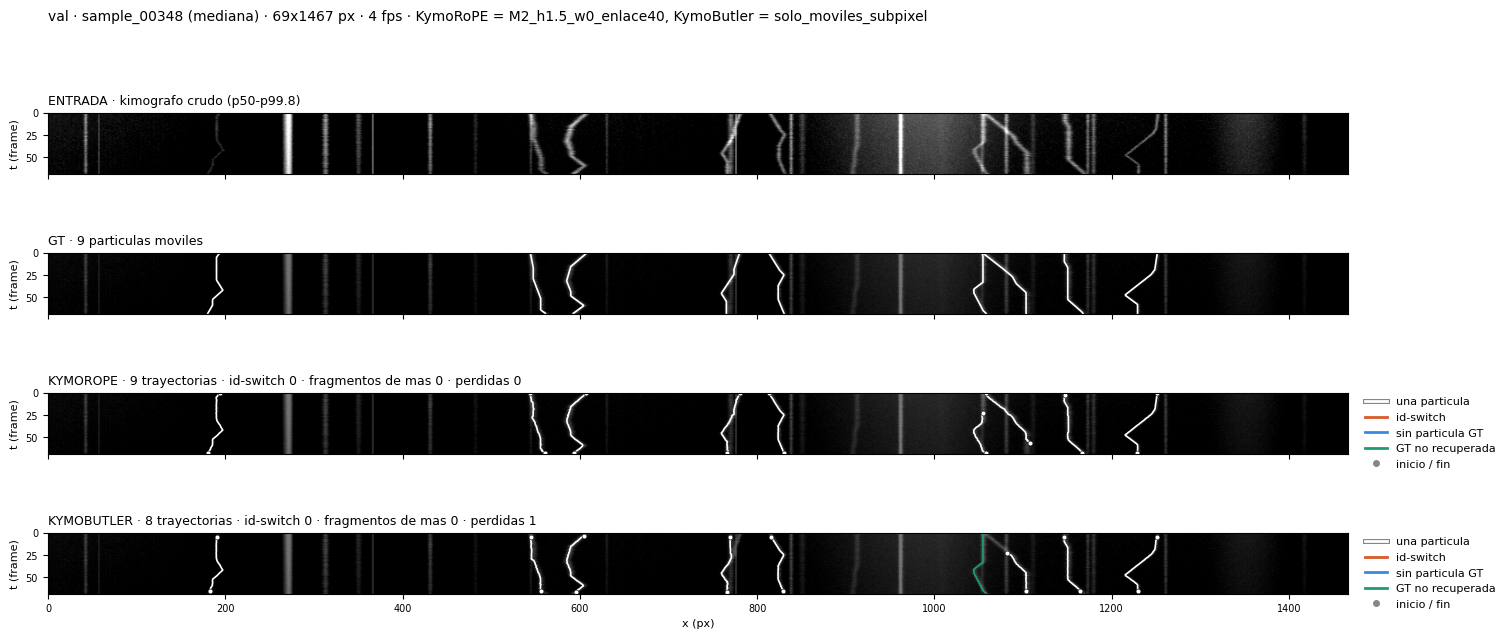

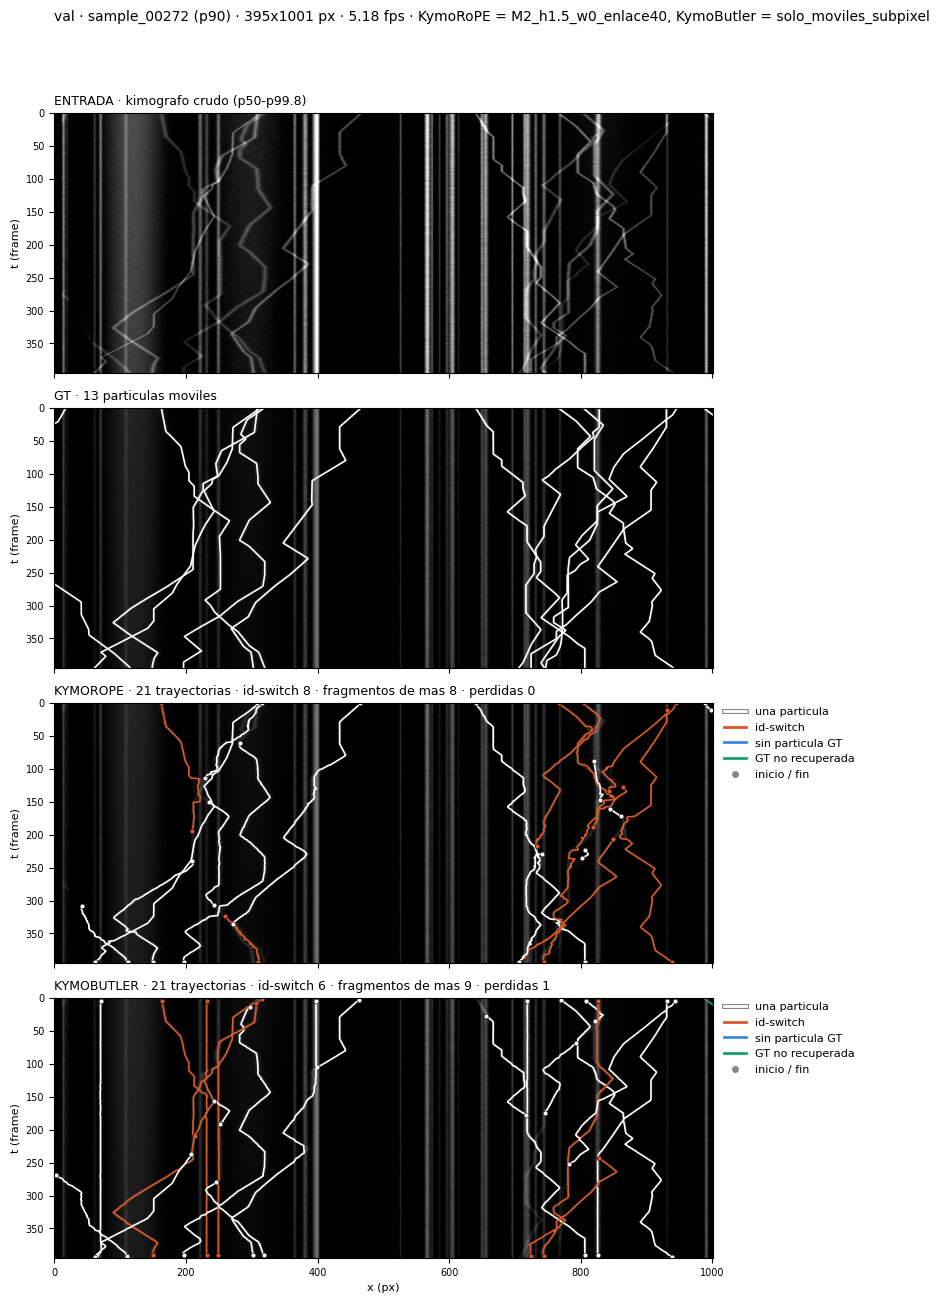

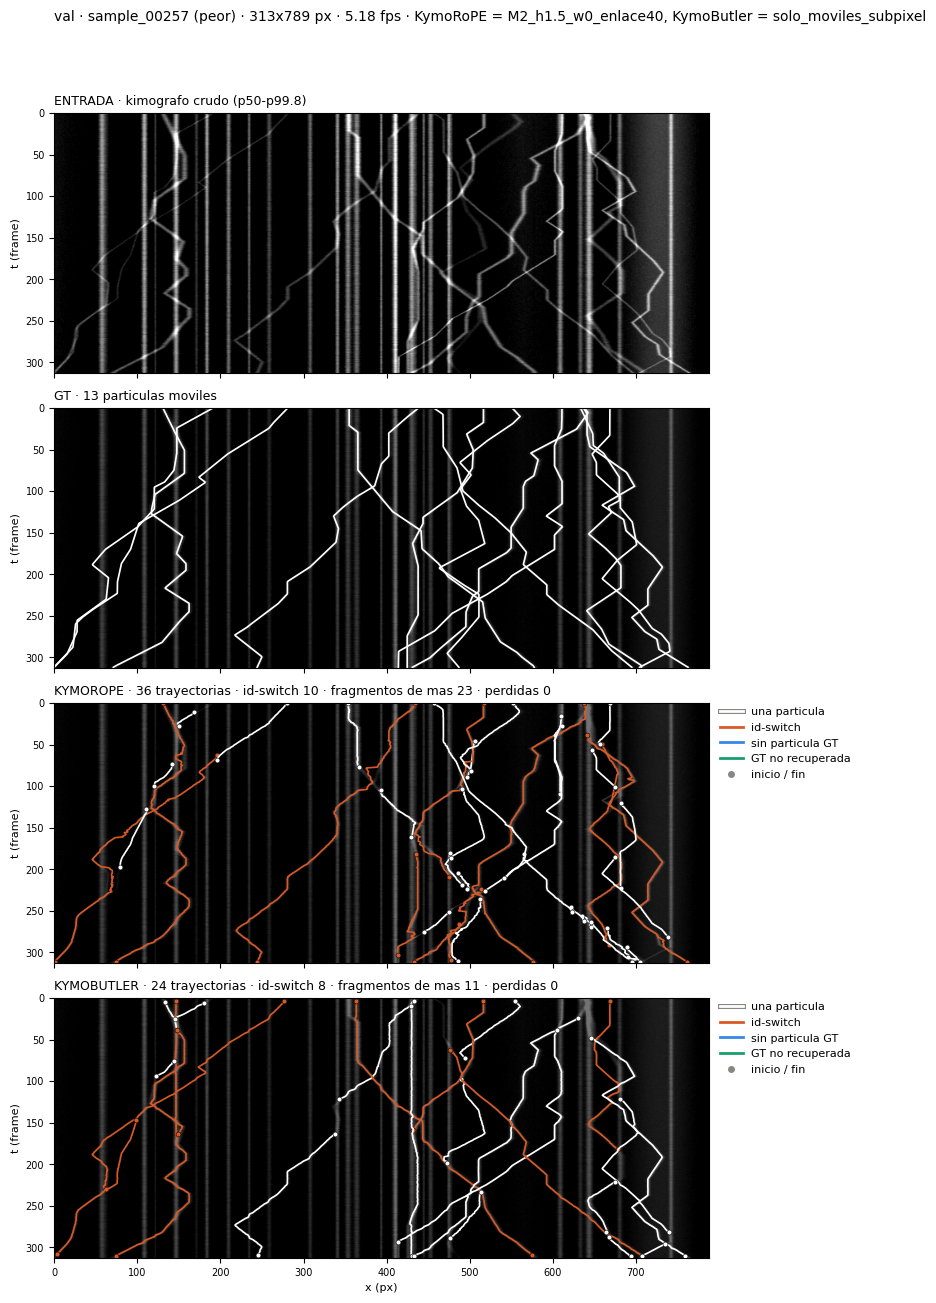

In [5]:
err_kr = errores_por_muestra(tr_kr, esc_kr)
err_kb = errores_por_muestra(tr_kb, esc_kb)
candidatas = err_kr[err_kr.moviles >= 2].sort_values("errores", kind="stable")
elegidas = {
    et: candidatas.index[round(q * (len(candidatas) - 1))]
    for et, q in (("mediana", 0.5), ("p90", 0.9), ("peor", 1.0))
}
elegidas.update({n: n for n in MUESTRAS_EXTRA})
display(
    pd.concat({"KymoRoPE": err_kr, "KymoButler": err_kb}, axis=1)
    .loc[list(elegidas.values())]
    .assign(caso=list(elegidas))
    .set_index("caso", append=True)
)
for etiqueta, nombre in elegidas.items():
    fig = ver_comparacion(nombre, etiqueta)
    plt.show()
    plt.close(fig)

---

## 4. El decode por dentro, sobre una muestra

Lo que hace `decodificar` en cada paso, en vivo (un forward del modelo). Útil para entender de
dónde sale un error de las superposiciones de arriba: ¿la máscara móvil vino cortada, el
agrupamiento fundió dos trazas, o el enlace unió fragmentos equivocados?


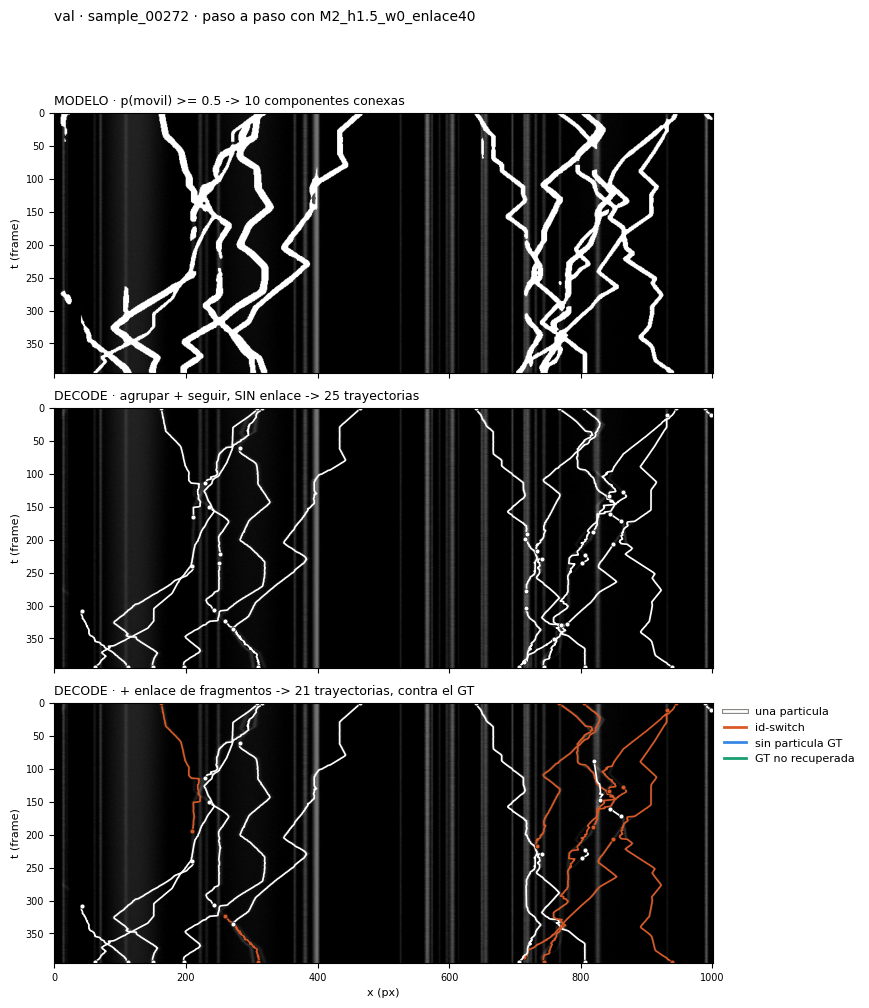

In [6]:
from scipy.ndimage import label

MUESTRA_PASO = elegidas["p90"]  # cualquier nombre de val sirve

ck = torch.load(CHECKPOINT, map_location=kr.dispositivo_preferido(), weights_only=False)
modelo = kr.KymoRoPE().to(kr.dispositivo_preferido()).eval()
modelo.load_state_dict(ck["model_state_dict"])
cache = RAIZ / "results" / "kymorope" / "cache" / SPLIT
ds = dp.DatasetKymografos(
    RAIZ / "datasets" / SPLIT, cache_dir=cache if cache.exists() else None
)
muestra = ds[[d.name for d in ds.dirs].index(MUESTRA_PASO)]
escena = escenas[MUESTRA_PASO]
with torch.no_grad():
    mapas = dc.mapas_desde_salida(modelo([muestra])[0])

mascara = mapas.p_movil >= PARAMS_PUNTO.umbral_movil
_, n_componentes = label(mascara, structure=np.ones((3, 3), int))
sin_enlace = dc.decodificar(
    mapas, escena["kymo"], replace(PARAMS_PUNTO, max_hueco_enlace=0)
)
con_enlace = dc.decodificar(mapas, escena["kymo"], PARAMS_PUNTO)
tr_paso, _ = ev.evaluar_trayectorias_polilineas(
    {MUESTRA_PASO: {**escena, "polilineas": con_enlace}}, min_desplazamiento_px=MIN_DESP
)

alto_px, ancho_px = escena["kymo"].shape
esc = min(13.0 / ancho_px, 2.6 / alto_px)
ancho, alto = ancho_px * esc, alto_px * esc
izq, der, sup, inf, titulo = 0.7, 2.4, 0.8, 0.5, 0.35
hueco = max(alto, 1.05)
W, H = izq + ancho + der, sup + 3 * (titulo + hueco) + inf
fig = plt.figure(figsize=(W, H))
axs, cursor = [], H - sup
for _ in range(3):
    cursor -= titulo + alto
    axs.append(fig.add_axes([izq / W, cursor / H, ancho / W, alto / H]))
    cursor -= hueco - alto

fondo = _lienzo(escena["kymo"])
lz = np.repeat(fondo[..., None], 3, axis=-1)
lz[mascara] = mcolors.to_rgb(C_OK)
axs[0].imshow(lz, aspect="auto")
axs[0].set_title(
    f"MODELO · p(movil) >= {PARAMS_PUNTO.umbral_movil} -> {n_componentes} componentes conexas",
    loc="left",
    fontsize=9,
)
axs[1].imshow(fondo, cmap="gray", vmin=0, vmax=1, aspect="auto")
for poli in sin_enlace:
    axs[1].plot(poli.col_subpixel, poli.frame, color=C_OK, lw=1.2)
    axs[1].plot(
        poli.col_subpixel.iloc[[0, -1]],
        poli.frame.iloc[[0, -1]],
        "o",
        color=C_OK,
        ms=3.5,
        mec="black",
        mew=0.4,
    )
axs[1].set_title(
    f"DECODE · agrupar + seguir, SIN enlace -> {len(sin_enlace)} trayectorias",
    loc="left",
    fontsize=9,
)
axs[2].imshow(fondo, cmap="gray", vmin=0, vmax=1, aspect="auto")
dibujar_metodo(axs[2], escena, con_enlace, tr_paso)
axs[2].set_title(
    f"DECODE · + enlace de fragmentos -> {len(con_enlace)} trayectorias, contra el GT",
    loc="left",
    fontsize=9,
)
leyenda_resultados(axs[2], con_extremos=False)
for ax in axs:
    ax.set_xlim(-0.5, ancho_px - 0.5)
    ax.set_ylim(alto_px - 0.5, -0.5)
    ax.set_ylabel("t (frame)", fontsize=8)
    ax.tick_params(labelsize=7)
for ax in axs[:-1]:
    ax.set_xticklabels([])
axs[-1].set_xlabel("x (px)", fontsize=8)
fig.suptitle(
    f"{SPLIT} · {MUESTRA_PASO} · paso a paso con {PUNTO}",
    x=izq / W,
    y=1 - 0.12 / H,
    ha="left",
    va="top",
    fontsize=10,
)
plt.show()
plt.close(fig)

---

## 5. Lectura — val, 400 muestras (corrida del 2026-09-24)

_Texto fijo, escrito sobre esa corrida; las tablas de arriba son las vivas._

**Val es representativo.** KymoButler en val (F1 0.972, id-switch 0.105, 1.273 trayectorias por
partícula, 0.032 µm) calca su cifra publicada de test (0.968 / 0.103 / 1.282 / 0.032).

**El decode ya no es el cuello de botella.** Con trackness e identidad GT (D0): F1 0.998,
id-switch 0.024 — el piso de la métrica en esta ruta de extracción — y 1.12 trayectorias por
partícula. Lo que queda de error abajo es del modelo.

**Contra KymoButler, KymoRoPE empata pero no gana.** Punto de operación elegido en val
(`M2_h1.5_w0_enlace40`):

|                                     | KymoButler |  KymoRoPE |        |
| ----------------------------------- | ---------: | --------: | ------ |
| F1                                  |      0.972 | **0.977** | gana   |
| id-switch                           |  **0.105** |     0.116 | pierde |
| trayectorias por partícula          |  **1.273** |     1.336 | pierde |
| error de posición (µm)              |  **0.032** |     0.049 | pierde |
| id-switch + partículas fragmentadas |      0.308 |     0.308 | empate |

El barrido de ancho de banda traza una curva id-switch ↔ fragmentación (h=1: 0.074 / 1.74; h=2
con enlace: 0.146 / 1.275) y el punto de KymoButler queda apenas por dentro de ella. No pasa el
gate en val.

**Dónde se decide: en los cruces, y ahí pierde.** Sobre partículas que no tocan a ninguna otra
(60% de las móviles), KymoRoPE fragmenta menos de la mitad que KymoButler (2.9% contra 7.1% de
partículas partidas) con el mismo id-switch (0.001). Sobre las que cruzan, pierde en todo:
id-switch 0.219 contra 0.210, 1.81 contra 1.56 trayectorias por partícula, 0.063 contra 0.037 µm.
Es justo el caso para el que existe el embedding.

**La escalera dice cuánto aporta el embedding.** Con la máscara GT, el id-switch baja de 0.183
sin identidad (D1) a 0.100 con el embedding del modelo (D2), contra 0.024 del oráculo: recupera
alrededor de la mitad de la brecha. Consistente con NB12 §9 (clusters flojos en val) y con el
sobreajuste del head de embedding (15.7× entre train y val).

**El error de posición es del decode, no del modelo.** Sin agrupar, la máscara del modelo da
0.036 µm (M1), cerca de KymoButler; agrupar por embedding lo sube a ~0.048, porque el cluster se
queda con parte de los píxeles de una fila y la línea central se corre. Se arregla sacando el
centro de la corrida completa de la máscara y dejando al cluster sólo la identidad.

**Aspect ratio: sin ventaja clara.** KymoRoPE fragmenta algo menos en kimógrafos anchos y tiene
algo más de id-switch; en los altos (muchos frames, más cruces) los dos rondan 0.18 de id-switch.

### Próximos pasos, de más barato a más caro

1. **Decode** — _implementado el 2026-09-26, todavía sin medir en val_: centro de fila desde la
   corrida completa de la máscara (`ParametrosDecode.centro_desde_mascara`) y enlace estricto en
   zonas densas (`margen_enlace`, `max_dist_emb_denso`). `scripts/evaluar_kymorope.py` trae filas
   que los apagan de a uno (`_centro_cluster`, `_enlace_laxo`) y una con los dos apagados
   (`_antes`) que tiene que reproducir la corrida de esta lectura.
2. **Modelo**: la identidad en los cruces es el cuello. Más datos sintéticos contra el
   sobreajuste del embedding, o más margen / dimensión en la pérdida discriminativa.
3. **Test**: una sola corrida con `M2_h1.5_w0_enlace40` fijo, cuando valga la pena gastarla.
